In [ ]:
from google.colab import drive
drive.mount("/content/drive")
# from google.colab import uploade

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/v_data/v_data"

In [ ]:
!pip install tensorflow
!pip install keras

from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
import os
# os.chdir("C:\\Users\\romi\\Desktop\\Python_ scripts")
img_width, img_height = 224, 224
train_data_dir = os.path.join(base_path,'train')
validation_data_dir = os.path.join(base_path,'test')
nb_train_samples = 400
nb_validation_samples = 100
epochs = 15
batch_size = 16
num_filters = 8
filter_size = 3
if K.image_data_format() == 'channels_first':
  input_shape = (3, img_width, img_height)
else:
  input_shape = (img_width, img_height, 3)

In [ ]:
train_datagen = ImageDataGenerator(
rescale = 1. / 255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)
test_datagen = ImageDataGenerator(rescale = 1. / 255)
train_generator = train_datagen.flow_from_directory(train_data_dir,

target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')
validation_generator = test_datagen.flow_from_directory(

validation_data_dir,
target_size =(img_width, img_height),
batch_size = batch_size, class_mode ='categorical')

Found 400 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential()
model.add(Conv2D(num_filters, (3,3), input_shape = input_shape, padding= "same"))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(num_filters - 3, (3,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Activation('relu'))
model.add(Flatten())
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))

# model.add(Dropout(0.2))
model.add(Dense(24))
model.add(BatchNormalization())
model.add(Activation('relu'))

# model.add(Dropout(0.2))
model.add(Dense(2))
model.add(Activation('softmax'))
print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 224, 224, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 224, 224, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 110, 110, 5)    │           365 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 110, 110, 5)    │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 55, 55, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 55, 55, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 15125)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │       484,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,739 (1.85 MB)

 Trainable params: 485,601 (1.85 MB)

 Non-trainable params: 138 (552.00 B)

None


In [ ]:
model.compile(loss ='binary_crossentropy',
optimizer ='rmsprop',

metrics =['accuracy'])

history = model.fit(train_generator,
steps_per_epoch = nb_train_samples // batch_size,
epochs = epochs, validation_data = validation_generator,
validation_steps = nb_validation_samples // batch_size
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 238ms/step - accuracy: 0.7222 - loss: 0.5692 - val_accuracy: 0.5208 - val_loss: 0.7553
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 396ms/step - accuracy: 0.8630 - loss: 0.3595 - val_accuracy: 0.5000 - val_loss: 0.9573
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.8930 - loss: 0.3029 - val_accuracy: 0.5000 - val_loss: 1.3522
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.9193 - loss: 0.2798 - val_accuracy: 0.4896 - val_loss: 1.1729
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.9226 - loss: 0.2536 - val_accuracy: 0.5000 - val_loss: 1.5820
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.9318 - loss: 0.2310 - val_accuracy: 0.5000 - val_loss: 1.6619
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.9509 - loss: 0.1756 - val_accuracy: 0.5000 - val_loss: 1.4497
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 416ms/step - accuracy: 0.9296 - loss: 0.2023 - val_accuracy:

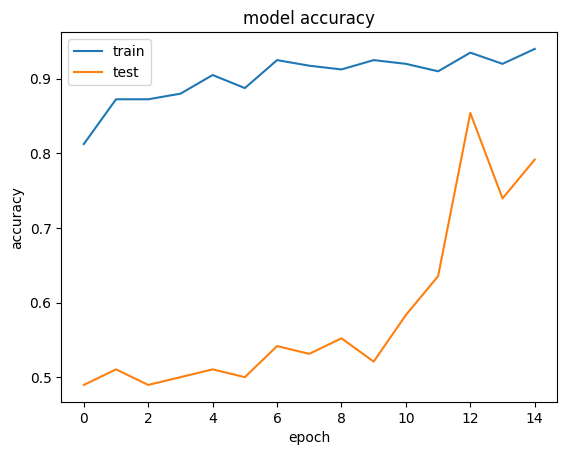

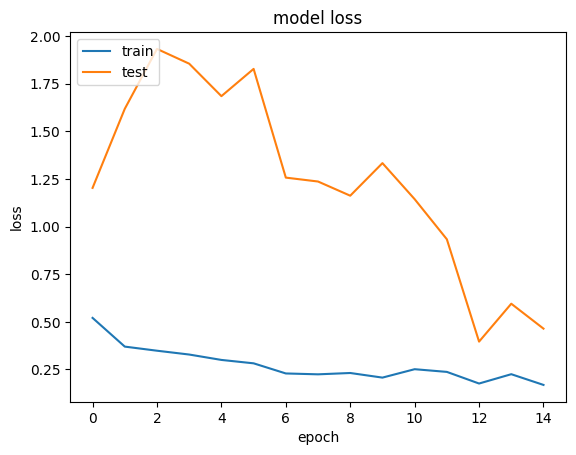

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
rescale = 1. / 255,
shear_range = 0.2,
zoom_range = 0.2,
horizontal_flip = True)

In [ ]:
train_datagen.ImageDataGenerator(rescale = 1. / 255)